# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

In [85]:
# 1. Read tic-tac-toe.csv into a dataframe.

df = pd.read_csv('tic-tac-toe.csv')

# 2. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
# We can see in the following code that the data set is realiable, the results of the games are correct and there are not Null values. 
print(df.sample(10))
print()
print(df.info())

    TL TM TR ML MM MR BL BM BR  class
829  o  o  o  x  b  b  x  x  b  False
771  o  x  x  b  o  o  x  x  o  False
155  x  o  o  x  x  b  x  b  o   True
94   x  x  o  o  x  b  b  x  o   True
223  x  b  x  x  o  o  x  o  b   True
146  x  o  o  x  x  x  o  o  x   True
421  o  o  b  b  b  b  x  x  x   True
639  x  x  o  x  b  o  b  b  o  False
506  b  x  o  o  x  b  o  x  x   True
850  o  b  x  x  o  x  x  o  o  False

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   TL      958 non-null    object
 1   TM      958 non-null    object
 2   TR      958 non-null    object
 3   ML      958 non-null    object
 4   MM      958 non-null    object
 5   MR      958 non-null    object
 6   BL      958 non-null    object
 7   BM      958 non-null    object
 8   BR      958 non-null    object
 9   class   958 non-null    bool  
dtypes: bool(1), object(9)
memory usage: 68.

In [86]:
# 3. Convert the categorical values to numeric in all columns.

mapping = {'x':1, 'o':-1, 'b':0}

for col in df.columns[:-1]:
    df[col] = df[col].map(mapping)

df['class'] = df['class'].astype(int)

print(df.sample(10)) # We can see in this line of code that all the columns have now numeric values. 

     TL  TM  TR  ML  MM  MR  BL  BM  BR  class
679   1  -1   1  -1  -1   1   1  -1   0      0
662   1   1   0   1   0   0  -1  -1  -1      0
53    1   1   1   0  -1   1  -1  -1   0      1
623   0   0   0  -1  -1   0   1   1   1      1
455  -1   0   1   0  -1  -1   1   1   1      1
833  -1  -1  -1  -1   1   1   1   0   1      0
340  -1   1  -1   0   1   0   1   1  -1      1
667   1   1   0  -1  -1  -1  -1   1   1      0
719   1   0  -1   1  -1   1  -1   1  -1      0
711   1   0   1  -1  -1  -1   1   0   0      0


In [87]:
# 4. Separate the inputs and output.

X = df.iloc[:, :-1]
y = df.iloc[:, -1]


# Split the training and test data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 1,
    stratify = y
)
print("TRAIN DATA:")
print(X_train.shape)
print(y_train.shape)
print()
print("TEST DATA:")
print(X_test.shape)
print(y_test.shape)

TRAIN DATA:
(766, 9)
(766,)

TEST DATA:
(192, 9)
(192,)


In [88]:
# 5. Normalize the input data.

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [89]:
# ARQUITECTURA DEL MODELO
# ------------------------

# Modelo secuencial
model = Sequential()

# Capa de entrada (9 features)
model.add(Input(shape=(9,)))

# Capas ocultas (3 capas estables de 64 neuronas)
# Clasificación: activation='relu'
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# Capa de salida 
model.add(Dense(1, activation='sigmoid'))

# Resumen de la arquitectura
model.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 64)                640       
                                                                 
 dropout_9 (Dropout)         (None, 64)                0         
                                                                 
 dense_14 (Dense)            (None, 64)                4160      
                                                                 
 dropout_10 (Dropout)        (None, 64)                0         
                                                                 
 dense_15 (Dense)            (None, 1)                 65        
                                                                 
Total params: 4865 (19.00 KB)
Trainable params: 4865 (19.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [90]:
# 4. Compile the model using adam as the optimizer and sparse_categorical_crossentropy as the loss function. 
# For metrics, use accuracy for now. 

model.compile(
    optimizer=Adam(learning_rate=0.001),    # O puede ser:  Adam(learning_rate=0.001)
    loss='binary_crossentropy',
    metrics=['accuracy'])
# loss='binary_crossentropy'              # Si es sigmoide
# loss='categorical_crossentropy'         # Si es softmax y está en one-hot encoding (0,1)
# loss='sparse_categorical_crossentropy'  # Si es softmax y está como enteros (0,1,2...)

early_stop = EarlyStopping(
    monitor='val_loss',           # Métrica a monitorear; o bien: 'val_accuracy' (clasif), 'val_mae' (regr)
    patience=10,                  # Epochs sin mejora antes de detener
    min_delta=1e-4,                # Lo que se considera "mejora"
    restore_best_weights=True,    # Restaurar pesos del MEJOR epoch
    verbose=1)                    # Mostrar mensaje al detener

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                                # Iteraciones completas del dataset
    batch_size=16,                             # Muestras por actualización de pesos
    validation_split=0.2,     # Evaluar durante entrenamiento
    callbacks=[early_stop],                    # Usar Early Stop
    verbose=1)                                 # Mostrar progreso


Epoch 1/100
39/39 [==============================] - 1s 13ms/step - loss: 0.6490 - accuracy: 0.6307 - val_loss: 0.6502 - val_accuracy: 0.6104
Epoch 2/100
39/39 [==============================] - 0s 6ms/step - loss: 0.6002 - accuracy: 0.6667 - val_loss: 0.6332 - val_accuracy: 0.6104
Epoch 3/100
39/39 [==============================] - 0s 4ms/step - loss: 0.5697 - accuracy: 0.6879 - val_loss: 0.6137 - val_accuracy: 0.6558
Epoch 4/100
39/39 [==============================] - 0s 4ms/step - loss: 0.5512 - accuracy: 0.7320 - val_loss: 0.6118 - val_accuracy: 0.6688
Epoch 5/100
39/39 [==============================] - 0s 4ms/step - loss: 0.5397 - accuracy: 0.7402 - val_loss: 0.6037 - val_accuracy: 0.6688
Epoch 6/100
39/39 [==============================] - 0s 4ms/step - loss: 0.5275 - accuracy: 0.7402 - val_loss: 0.6041 - val_accuracy: 0.6753
Epoch 7/100
39/39 [==============================] - 0s 4ms/step - loss: 0.5122 - accuracy: 0.7402 - val_loss: 0.5969 - val_accuracy: 0.6948
Epoch 8/100


In [94]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Loss: 0.039
Test Accuracy: 98.96%


In [95]:
# Evaluate your neural network model with the test data.
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()


6/6 [==============================] - 0s 3ms/step


In [96]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 66   1]
 [  1 124]]


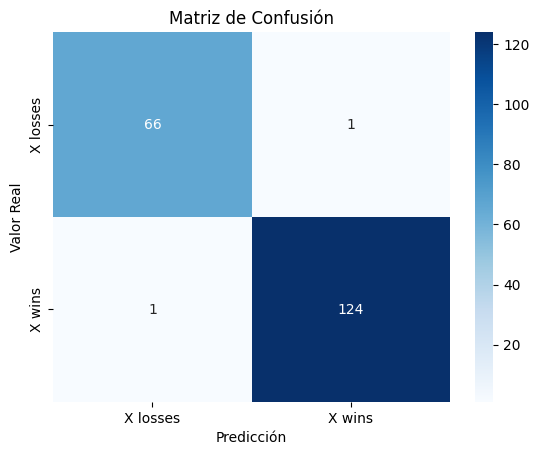

In [97]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['X losses', 'X wins'],
    yticklabels=['X losses', 'X wins'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()


In [ ]:
# Save your model as tic-tac-toe.model.
model.save("tic-tac-toe.model")

## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [99]:
# choose 5 random indices
random_indices = np.random.choice(len(X_test), size=5, replace=False)

for i in random_indices: 
    print(f"Index: {i} => Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")


Index: 65 => Predicted: 0, Actual: 0
Index: 21 => Predicted: 1, Actual: 1
Index: 22 => Predicted: 1, Actual: 1
Index: 167 => Predicted: 1, Actual: 1
Index: 188 => Predicted: 1, Actual: 1


## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

In [ ]:
# As my model has a Test Loss: 0.039 and Test Accuracy: 98.96% It does not need improvement.

**Which approach(es) did you find helpful to improve your model performance?**

In [ ]:
# your answer here